# Model Training

**Objective:** Train a regressor (predict quantity) and a classifier (predict demand tier) using image embeddings, price, and **training-set augmentation**.

**Inputs:** `data/processed/training_set.csv` (180 rows × 2048 image features + price + target)

**Methodology:**
1. **Split first.** Stratified 80/20 split on demand tier — done before any augmentation to prevent test leakage.
2. **Augment training only.** Each training image is re-embedded under five augmentation transforms (horizontal flip, colour jitter, rotation, random-resized crop, flip+jitter). Combined with the original, this gives 6× the training data. The test split remains the 36 untouched original images.
3. **PCA on originals.** Fit on the original 180 embeddings; augmented training embeddings are transformed through the same PCA so all features live in a consistent space.
4. **Random Forest regressor** (shallow, regularised) predicts quantity.
5. **Random Forest classifier** (balanced class weights) predicts demand tier.

**Outputs:** `models/regressor.pkl`, `models/classifier.pkl`, `models/scaler.pkl`, `models/pca.pkl`, `models/feature_columns.csv`, `models/metrics.json`, three diagnostic plots in `outputs/`.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path('..').resolve()
sys.path.append(str(PROJECT_ROOT))

from src.feature_extractor import (build_augmentations, extract_with_transform,
                                     load_resnet50_extractor)
from src.model import (TIER_BOUNDARIES, TIER_LABELS, assign_demand_tier,
                        build_classifier, build_regressor, cross_validate_mae,
                        evaluate_classification, evaluate_regression,
                        save_artifacts)

PROCESSED = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
OUTPUTS_DIR.mkdir(exist_ok=True)
RANDOM_SEED = 42
PCA_COMPONENTS = 16
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

## 1. Load data and derive tier target

In [2]:
df = pd.read_csv(PROCESSED / 'training_set.csv')
embedding_cols = [c for c in df.columns if c.startswith('emb_')]
X_emb = df[embedding_cols].values.astype(np.float32)
X_rate = df[['avg_rate']].values.astype(np.float32)
y_qty = df['total_qty'].values.astype(np.float32)
y_tier = assign_demand_tier(y_qty)
paths = df['path'].tolist()

print(f'Total samples : {len(df)}')
print(f'Tier counts   : {dict(pd.Series(y_tier).value_counts().sort_index())}')
print(f'Target range  : min {y_qty.min():.0f}, median {np.median(y_qty):.1f}, max {y_qty.max():.0f}')

Total samples : 180
Tier counts   : {0: 55, 1: 87, 2: 38}
Target range  : min 3, median 12.0, max 110


## 2. Stratified split (before any augmentation)

In [3]:
indices = np.arange(len(df))
idx_train, idx_test = train_test_split(
    indices, test_size=0.2, stratify=y_tier, random_state=RANDOM_SEED
)

X_emb_train_orig = X_emb[idx_train]
X_emb_test = X_emb[idx_test]
X_rate_train = X_rate[idx_train]
X_rate_test = X_rate[idx_test]
y_train = y_qty[idx_train]
y_test = y_qty[idx_test]
tier_train = y_tier[idx_train]
tier_test = y_tier[idx_test]
train_paths = [paths[i] for i in idx_train]

print(f'Train: {len(idx_train)} samples')
print(f'Test : {len(idx_test)} samples')

Train: 144 samples
Test : 36 samples


## 3. Augment training images (5 variants × 144 = 720 extra training samples)

Each training image is re-embedded under five different transforms. The augmented embeddings are stacked with the originals to form a 6× training set. The test split is untouched.

In [4]:
extractor = load_resnet50_extractor(device='cpu')
augmentations = build_augmentations()
print('Augmentations:', list(augmentations.keys()))

augmented_embs = {}
for name, transform in augmentations.items():
    print(f'  generating {name} embeddings...')
    augmented_embs[name] = extract_with_transform(train_paths, transform, extractor)

print('Done. Each augmentation produced', augmented_embs['flip'].shape, 'embeddings.')

Augmentations: ['flip', 'jitter', 'rotate', 'rrc', 'flip_jitter']
  generating flip embeddings...


  generating jitter embeddings...


  generating rotate embeddings...


  generating rrc embeddings...


  generating flip_jitter embeddings...


Done. Each augmentation produced (144, 2048) embeddings.


## 4. PCA fit on original training embeddings

PCA components are learned from the 144 original training embeddings only. Augmented embeddings are projected through the same fitted PCA so they live in the same feature space.

In [5]:
pca = PCA(n_components=PCA_COMPONENTS, random_state=RANDOM_SEED)
pca.fit(X_emb_train_orig)
var_explained = pca.explained_variance_ratio_.sum()

X_pca_train_orig = pca.transform(X_emb_train_orig)
X_pca_train_aug = {name: pca.transform(emb) for name, emb in augmented_embs.items()}
X_pca_test = pca.transform(X_emb_test)

print(f'PCA variance explained: {var_explained:.3f} ({var_explained * 100:.1f}%)')

PCA variance explained: 0.557 (55.7%)


## 5. Assemble final feature matrices

In [6]:
feature_cols = [f'pca_{i}' for i in range(PCA_COMPONENTS)] + ['avg_rate']

X_train_blocks = [np.hstack([X_pca_train_orig, X_rate_train])]
for name in augmentations:
    X_train_blocks.append(np.hstack([X_pca_train_aug[name], X_rate_train]))

X_train = np.vstack(X_train_blocks)
y_train_aug = np.tile(y_train, len(X_train_blocks))
tier_train_aug = np.tile(tier_train, len(X_train_blocks))
X_test = np.hstack([X_pca_test, X_rate_test])

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'Train matrix : {X_train_s.shape}  (6\u00d7 = {len(X_train_blocks)}\u00d7 augmented)')
print(f'Test matrix  : {X_test_s.shape}')

Train matrix : (864, 17)  (6× = 6× augmented)
Test matrix  : (36, 17)


## 6. Train regressor

In [7]:
regressor = build_regressor(n_features=X_train_s.shape[1], random_state=RANDOM_SEED)
cv_mean, cv_std = cross_validate_mae(regressor, X_train_s, y_train_aug,
                                       n_splits=5, random_state=RANDOM_SEED)
regressor.fit(X_train_s, y_train_aug)
reg_result = evaluate_regression(regressor, X_test_s, y_test, cv_mean, cv_std)

print('Regression')
print(f'  CV MAE (5-fold) : {reg_result.cv_mae_mean:6.2f} \u00b1 {reg_result.cv_mae_std:.2f}')
print(f'  Test MAE        : {reg_result.mae:6.2f}')
print(f'  Test RMSE       : {reg_result.rmse:6.2f}')
print(f'  Test R\u00b2         : {reg_result.r2:6.3f}')

baseline_pred = np.full_like(y_test, y_train.mean())
baseline_mae = float(np.mean(np.abs(y_test - baseline_pred)))
print(f'  Baseline (mean) : {baseline_mae:6.2f}  -> beats baseline: {reg_result.mae < baseline_mae}')

Regression
  CV MAE (5-fold) :   8.99 ± 0.14
  Test MAE        :  10.60
  Test RMSE       :  14.99
  Test R²         :  0.341
  Baseline (mean) :  13.78  -> beats baseline: True


## 7. Train classifier

In [8]:
classifier = build_classifier(random_state=RANDOM_SEED)
classifier.fit(X_train_s, tier_train_aug)
clf_result = evaluate_classification(classifier, X_test_s, tier_test)

print('Classification')
print(f'  Accuracy   : {clf_result.accuracy:.3f}')
print(f'  F1 (macro) : {clf_result.f1_macro:.3f}')
print(f'  F1 per class:')
for label, score in clf_result.f1_per_class.items():
    print(f'    {label:>6s} : {score:.3f}')

Classification
  Accuracy   : 0.528
  F1 (macro) : 0.488
  F1 per class:
       Low : 0.522
    Medium : 0.579
      High : 0.364


## 8. Empirical rate behaviour

In [9]:
sample_image = X_train_s[0, :-1]
rates = np.linspace(400, 1700, 6)
preds_over_rates = []
for rate in rates:
    rate_scaled = (rate - scaler.mean_[-1]) / scaler.scale_[-1]
    vec = np.concatenate([sample_image, [rate_scaled]]).reshape(1, -1)
    preds_over_rates.append(float(np.clip(regressor.predict(vec)[0], 1.0, None)))
for r, p in zip(rates, preds_over_rates):
    print(f'  rate={r:6.0f} -> qty={p:.2f}')
spread = float(max(preds_over_rates) - min(preds_over_rates))
print(f'Spread: {spread:.2f}')

  rate=   400 -> qty=86.17
  rate=   660 -> qty=13.62
  rate=   920 -> qty=18.63
  rate=  1180 -> qty=63.95
  rate=  1440 -> qty=34.27
  rate=  1700 -> qty=34.97
Spread: 72.55


## 9. Persist artefacts and metrics

In [10]:
save_artifacts(MODELS_DIR, regressor, classifier, scaler, pca, feature_cols)

metrics = {
    'regressor': {
        'model': 'RandomForestRegressor(n_estimators=300, max_depth=3, min_samples_leaf=5)',
        'cv_mae_mean': round(reg_result.cv_mae_mean, 3),
        'cv_mae_std': round(reg_result.cv_mae_std, 3),
        'test_mae': round(reg_result.mae, 3),
        'test_rmse': round(reg_result.rmse, 3),
        'test_r2': round(reg_result.r2, 3),
        'baseline_mae': round(baseline_mae, 3),
        'beats_baseline': bool(reg_result.mae < baseline_mae),
    },
    'classifier': {
        'model': 'RandomForestClassifier(n_estimators=300, max_depth=10, class_weight=balanced)',
        'accuracy': round(clf_result.accuracy, 3),
        'f1_macro': round(clf_result.f1_macro, 3),
        'f1_per_class': {k: round(v, 3) for k, v in clf_result.f1_per_class.items()},
        'confusion_matrix': clf_result.confusion,
        'tier_labels': list(TIER_LABELS),
        'tier_boundaries': list(TIER_BOUNDARIES),
    },
    'training': {
        'n_train_original': int(len(idx_train)),
        'n_train_augmented': int(len(X_train_s)),
        'n_test': int(len(X_test_s)),
        'augmentation_multiplier': len(X_train_blocks),
        'augmentations': list(augmentations.keys()),
        'pca_components': PCA_COMPONENTS,
        'pca_variance_explained': round(float(var_explained), 4),
        'random_seed': RANDOM_SEED,
    },
    'rate_sanity': {
        'sweep_min_qty': round(float(min(preds_over_rates)), 2),
        'sweep_max_qty': round(float(max(preds_over_rates)), 2),
        'sweep_spread': round(float(spread), 2),
    },
}
(MODELS_DIR / 'metrics.json').write_text(json.dumps(metrics, indent=2))
print('Saved.')
print(json.dumps(metrics, indent=2))

Saved.
{
  "regressor": {
    "model": "RandomForestRegressor(n_estimators=300, max_depth=3, min_samples_leaf=5)",
    "cv_mae_mean": 8.989,
    "cv_mae_std": 0.141,
    "test_mae": 10.596,
    "test_rmse": 14.99,
    "test_r2": 0.341,
    "baseline_mae": 13.782,
    "beats_baseline": true
  },
  "classifier": {
    "model": "RandomForestClassifier(n_estimators=300, max_depth=10, class_weight=balanced)",
    "accuracy": 0.528,
    "f1_macro": 0.488,
    "f1_per_class": {
      "Low": 0.522,
      "Medium": 0.579,
      "High": 0.364
    },
    "confusion_matrix": [
      [
        6,
        5,
        0
      ],
      [
        5,
        11,
        1
      ],
      [
        1,
        5,
        2
      ]
    ],
    "tier_labels": [
      "Low",
      "Medium",
      "High"
    ],
    "tier_boundaries": [
      10,
      25
    ]
  },
  "training": {
    "n_train_original": 144,
    "n_train_augmented": 864,
    "n_test": 36,
    "augmentation_multiplier": 6,
    "augmentations": [

## 10. Diagnostic plots

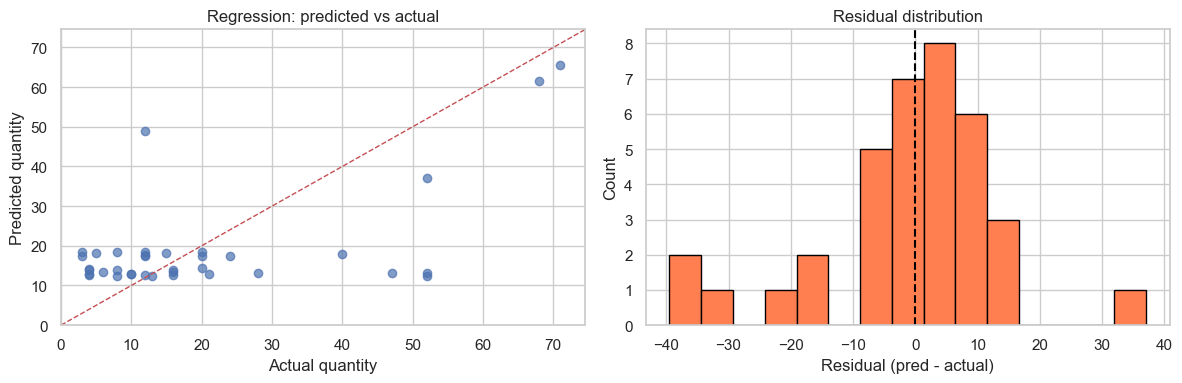

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
preds = np.clip(regressor.predict(X_test_s), 1.0, None)
lims = [0, max(y_test.max(), preds.max()) * 1.05]
axes[0].scatter(y_test, preds, alpha=0.7)
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel('Actual quantity')
axes[0].set_ylabel('Predicted quantity')
axes[0].set_title('Regression: predicted vs actual')

residuals = preds - y_test
axes[1].hist(residuals, bins=15, color='coral', edgecolor='black')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Residual (pred - actual)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual distribution')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'prediction_diagnostics.png', dpi=120)
plt.show()

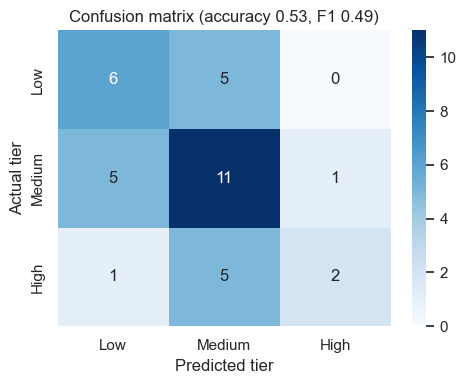

In [12]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(clf_result.confusion, annot=True, fmt='d', cmap='Blues',
             xticklabels=list(TIER_LABELS), yticklabels=list(TIER_LABELS), ax=ax)
ax.set_xlabel('Predicted tier')
ax.set_ylabel('Actual tier')
ax.set_title(f'Confusion matrix (accuracy {clf_result.accuracy:.2f}, F1 {clf_result.f1_macro:.2f})')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'confusion_matrix.png', dpi=120)
plt.show()

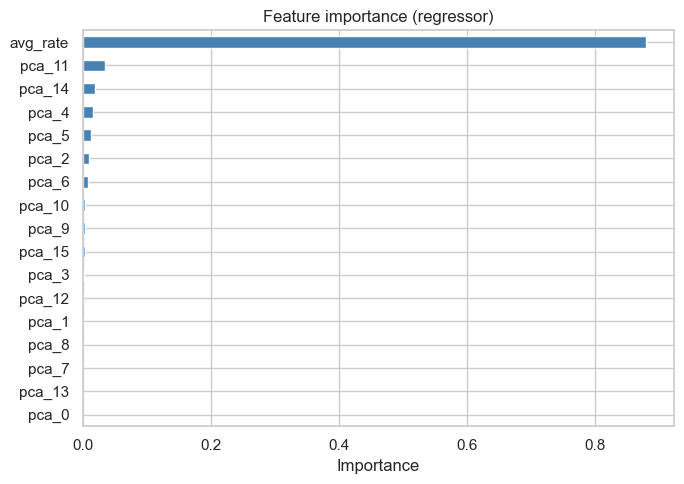

Top 5 features:
avg_rate    0.8793
pca_11      0.0343
pca_14      0.0198
pca_4       0.0167
pca_5       0.0136
dtype: float64


In [13]:
importances = pd.Series(regressor.feature_importances_, index=feature_cols)
fig, ax = plt.subplots(figsize=(7, 5))
importances.sort_values().plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Feature importance (regressor)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'feature_importance.png', dpi=120)
plt.show()

print('Top 5 features:')
print(importances.sort_values(ascending=False).head(5).round(4))